In [ ]:
# Colab bootstrap: clone repo and cd into it. Skipped if already present (local Jupyter).
import os
if not os.path.exists('HartyMaze_ReinforcementLearning'):
    !git clone https://github.com/IrvingGomez/HartyMaze_ReinforcementLearning.git
    %cd HartyMaze_ReinforcementLearning
os.makedirs('outputs', exist_ok=True)

# Harty and the Treasure Maze

Welcome! Harty is a fox who wants to find a treasure hidden inside a maze.
We will teach Harty the best plan (a *policy*) for getting to the treasure
no matter which cell he starts in.

The technique is called **Iterative Policy Improvement**. The idea:

1. Start with a random plan.
2. Score it: how good is every cell under this plan?
3. Improve the plan: at each cell, pick the action that leads to the best score.
4. Repeat until the plan stops changing.

Run every cell from top to bottom (Shift + Enter).


In [1]:
import sys
from pathlib import Path

# Make modules in src/ importable from this notebook.
sys.path.insert(0, str(Path.cwd() / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from environment import DEFAULT_MAZE, BIG_MAZE
from policy_iteration import policy_iteration, uniform_random_policy_value
from visualization import plot_policy_and_value, plot_value_only
from animation import animate_path, save_animation, simulate_path, uniform_random_action
from IPython.display import HTML, Image

## 1. How the maze is encoded

Every cell in the maze is given a number from **0 to 14**. The number tells
which walls that cell has. Here is the legend:

<img src="images/MouseMazeCode.png" width="600">

And here is the default maze with each cell's code drawn inside:

<img src="images/BigMaze_withcode.png" width="800">

Students who want to design their own maze just need to write a 2D array of
these numbers. Two neighbour cells should agree on shared walls (if cell A
says "right wall" then cell B on its right should say "left wall").


## 2. Choose your setup

Change the values below to play with the maze. Then rerun every cell.

- `MAZE` is a numpy array of wall codes (default supplied by the project).
- `TREASURE` is the (row, column) where the treasure sits.
- `HARTY` is the cell where Harty stands.
- `DISCOUNT_RATE` (gamma) decides how much Harty cares about future steps.
  Closer to 1 = patient; closer to 0 = short-sighted.
- `HOLES` is a list of cells that end the game with reward -1. Leave empty
  for none.
- `PORTALS` is a list of pairs of cells. Each pair teleports Harty between
  its two endpoints (either way). Up to two pairs are supported; leave the
  list empty for none.


In [ ]:
MAZE = BIG_MAZE     # replace with your own np.array of wall codes 0-14
TREASURE = (0, 15)
HARTY = (11, 12)
DISCOUNT_RATE = 0.99

HOLES = [(2,14),(14,16)]              # e.g. [(3, 3), (5, 7)] -- stepping here ends the game
PORTALS = [((3,0),(14,12)),((8,16),(12,17))]            # e.g. [((1, 1), (8, 8))] -- up to 2 pairs; both endpoints teleport

rows, cols = MAZE.shape

assert MAZE.ndim == 2, 'MAZE must be a 2D array'
assert MAZE.dtype.kind in 'iu', 'MAZE values must be integers'
assert MAZE.min() >= 0 and MAZE.max() <= 14, 'wall codes must be in 0..14'

assert 0 <= TREASURE[0] < rows and 0 <= TREASURE[1] < cols, 'TREASURE outside grid'
assert 0 <= HARTY[0] < rows and 0 <= HARTY[1] < cols, 'HARTY outside grid'
assert TREASURE != HARTY, 'TREASURE and HARTY cannot share a cell'

#trap_codes = {9, 10, 11, 12}
#assert int(MAZE[HARTY]) not in trap_codes, 'HARTY is in a fully-walled cell, he cannot move'

assert len(PORTALS) <= 2, 'at most two portal pairs are supported'
for pair in PORTALS:
    assert len(pair) == 2, 'each portal pair must have exactly two cells'

reserved = {TREASURE, HARTY, *HOLES}
for pair in PORTALS:
    for cell in pair:
        assert 0 <= cell[0] < rows and 0 <= cell[1] < cols, f'portal cell {cell} outside grid'
        assert cell not in reserved, f'portal cell {cell} clashes with treasure/Harty/hole'
        reserved.add(cell)

for hole in HOLES:
    assert 0 <= hole[0] < rows and 0 <= hole[1] < cols, f'hole {hole} outside grid'
    assert hole != TREASURE, 'hole cannot share a cell with the treasure'
    assert hole != HARTY, 'hole cannot share a cell with Harty'

print(f'Maze: {rows} x {cols}')
print(f'Treasure at {TREASURE}, Harty at {HARTY}, gamma = {DISCOUNT_RATE}')
print(f'Holes: {HOLES}')
print(f'Portals: {PORTALS}')

Maze: 19 x 18
Treasure at (0, 15), Harty at (1, 5), gamma = 0.99
Holes: [(2, 14), (14, 16)]
Portals: [((3, 0), (14, 12)), ((8, 16), (12, 17))]


## 3. The maze

Here is the empty maze with the treasure and Harty placed at the cells you
chose. No learning yet, just the picture.


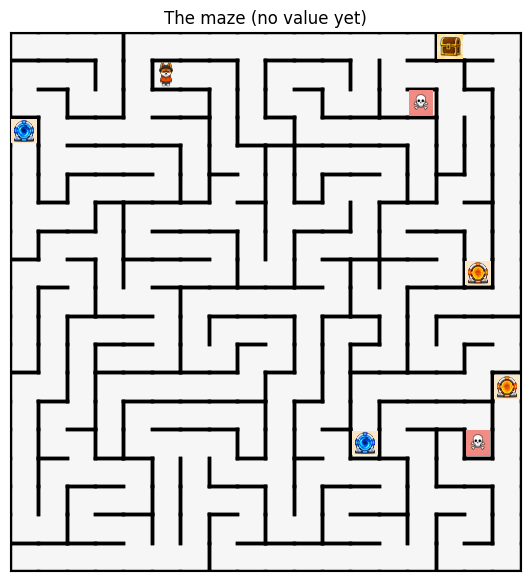

In [3]:
V_empty = np.zeros_like(MAZE, dtype=float)
fig, _ = plot_value_only(
    V_empty, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
    title='The maze (no value yet)',
)
plt.show()

## 4. Before learning -- the random walker

To start, let us see what happens if Harty walks **randomly** at every step
(each direction with probability 1/4). The colors below show the *value* of
each cell -- how often a random walk starting there ends at the treasure.

Hot colors (purple) = high value. Cold colors (red) = low value.

You will see that random walking is bad: most cells light up only a little.


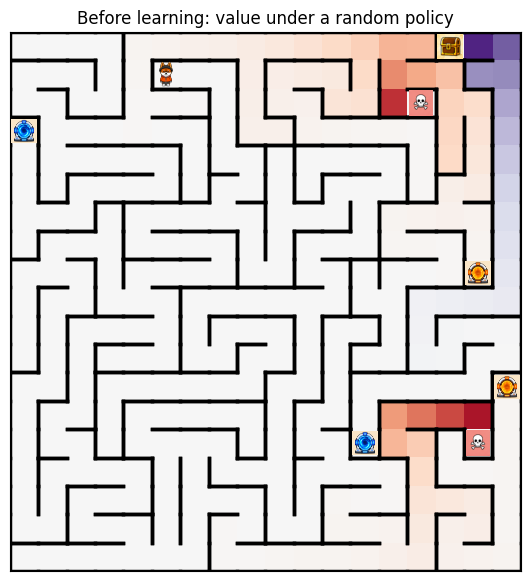

In [4]:
V_random = uniform_random_policy_value(
    TREASURE, DISCOUNT_RATE, MAZE,
    holes=HOLES, portals=PORTALS,
)

fig, _ = plot_value_only(
    V_random, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Before learning: value under a random policy',
)
plt.show()

### Watch Harty wander randomly

Each step Harty picks a direction at random with equal chance. You will
see him bump into walls, backtrack, and rarely reach the chest in time.


In [6]:
random_path = simulate_path(
    uniform_random_action, HARTY, TREASURE, MAZE,
    max_steps=80, seed=0,
    holes=HOLES, portals=PORTALS,
)
anim_random = animate_path(
    random_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    value=V_random,
    title='Harty wandering (showing value)',
)
#HTML(anim_random.to_jshtml()) # To show in the notebook

save_animation(anim_random, 'outputs/harty_random.gif', fps=2.5)

WindowsPath('outputs/harty_random.gif')

### Plain version -- just the maze and Harty

Same random walk, but without the value colors or any arrows. Useful for
introducing the maze without giving away the policy.


In [7]:
anim_random_plain = animate_path(
    random_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Harty wandering',
)
#HTML(anim_random_plain.to_jshtml()) # To show in the notebook

save_animation(anim_random_plain, 'outputs/harty_random_plain.gif', fps=2.5)

WindowsPath('outputs/harty_random_plain.gif')

## 5. After learning -- the best policy

Now we run **Iterative Policy Improvement**. Each cell gets an arrow telling
Harty the best direction to go from there. The colors show how good each
cell is under this learned plan.

If you follow the arrows starting from Harty's cell, you should reach the
treasure.


Policy iteration converged in 100 cycles.


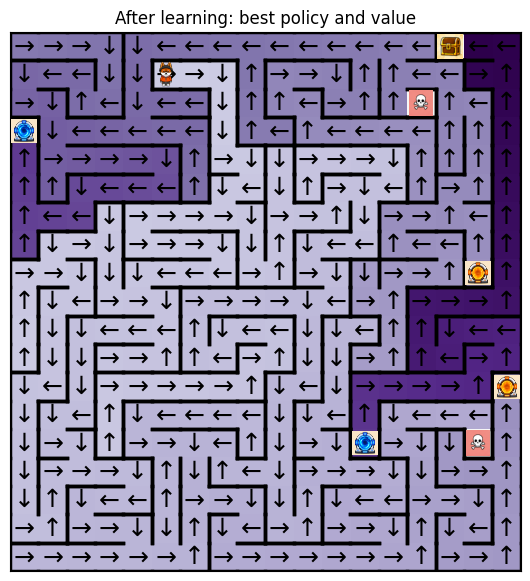

In [8]:
policy, V, cycles = policy_iteration(
    TREASURE, DISCOUNT_RATE, MAZE, seed=0,
    holes=HOLES, portals=PORTALS,
    n_eval_sweeps=200,
    max_cycles=100,
    tol=1e-3
)
print(f'Policy iteration converged in {cycles} cycles.')

fig, _ = plot_policy_and_value(
    policy, V, TREASURE, HARTY, MAZE,
    holes=HOLES, portals=PORTALS,
    title='After learning: best policy and value',
)
plt.show()

### Watch Harty follow the best policy

Now Harty obeys the arrows at every cell. He should walk straight to the
treasure with no backtracking.


In [10]:
best_path = simulate_path(
    policy, HARTY, TREASURE, MAZE, max_steps=200,
    holes=HOLES, portals=PORTALS,
)
anim_best = animate_path(
    best_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    value=V,
    policy=policy,
    title='Harty following the best policy (showing value and policy)',
)
#HTML(anim_best.to_jshtml()) # To show in the notebook

save_animation(anim_best, 'outputs/harty_best.gif', fps=2.5)

WindowsPath('outputs/harty_best.gif')

### Plain version -- just the maze and Harty

Same optimal walk, but without value colors or arrows. Pure focus on the
path Harty takes to reach the treasure.


In [11]:
anim_best_plain = animate_path(
    best_path, TREASURE, MAZE,
    holes=HOLES, portals=PORTALS,
    title='Harty following the best policy',
)
#HTML(anim_best_plain.to_jshtml()) # To show in the notebook

save_animation(anim_best_plain, 'outputs/harty_best_plain.gif', fps=2.5)

WindowsPath('outputs/harty_best_plain.gif')

## What to try next

- Move the treasure to a different cell (for example `(5, 5)`).
- Move Harty.
- Change `DISCOUNT_RATE` to `0.5` (impatient) or `0.99` (very patient).
- Build your own maze with the wall codes from section 1.

Rerun the notebook each time. The plan and the colors will update.
